<a href="https://colab.research.google.com/github/Balbir89/BikeSharingProject/blob/main/BikeSharing_Berlin_Cleaned_Combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load and Inspect Data

begin by uploading and loading the dataset into a GeoDataFrame using GeoPandas. this dataset contains information on 740,000+ bike trips, including:

Origin and destination coordinates, Timestamps for trip start and end Duration, distance, speed, Provider and bike ID, Geospatial geometry column for mapping etc.

This initial inspection helps me and verify the structure, column types, and ensure there are no missing critical values (like coordinates or timestamps) before proceeding with analysis and visualization.


In [21]:
import folium
import pandas as pd
df = pd.read_pickle("BikeSharingData_Berlin_combinedandcleaned.pkl")
df.info()
df.head()


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 740380 entries, 0 to 1931
Data columns (total 15 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   duration_osrm                      740380 non-null  float64 
 1   distance_osrm                      740380 non-null  float64 
 2   lat_origin                         740380 non-null  float64 
 3   long_origin                        740380 non-null  float64 
 4   lat_destination                    740380 non-null  float64 
 5   long_destination                   740380 non-null  float64 
 6   time_origin                        740380 non-null  int64   
 7   time_destination                   740380 non-null  int64   
 8   providerId                         740380 non-null  int64   
 9   bikeId                             596839 non-null  float64 
 10  geometry                           740380 non-null  geometry
 11  is_citylab               

,duration_osrm,distance_osrm,lat_origin,long_origin,lat_destination,long_destination,time_origin,time_destination,providerId,bikeId,geometry,is_citylab,speed_osrm,duration_betweenorigindestination,speed_kmh
0,1336.3,4286.3,52.503068,13.361295,52.523948,13.396664,1561820163,1561822084,0,13016.0,"LINESTRING (13.3613 52.50307, 13.36439 52.5099...",1,11.547317,1921,8.032629
2,386.4,1418.7,52.526327,13.393544,52.533942,13.405097,1561830723,1561832164,0,13016.0,"LINESTRING (13.39357 52.52633, 13.39293 52.527...",1,13.217702,1441,3.544289
3,1303.1,3912.1,52.494206,13.426127,52.496401,13.468012,1561829763,1561836005,0,13022.0,"LINESTRING (13.42613 52.49421, 13.42547 52.494...",1,10.807735,6242,2.256258
4,241.9,659.7,52.516347,13.310143,52.514350,13.316474,1561800483,1561801444,0,13025.0,"LINESTRING (13.31014 52.51635, 13.31046 52.516...",1,9.817776,961,2.471301
5,200.4,639.1,52.514350,13.316474,52.509942,13.314446,1561805523,1561806244,0,13025.0,"LINESTRING (13.31647 52.51434, 13.3152 52.5147...",1,11.480838,721,3.191068


In [22]:
import pandas as pd


In [23]:
print(df.columns)


Index(['duration_osrm', 'distance_osrm', 'lat_origin', 'long_origin',
       'lat_destination', 'long_destination', 'time_origin',
       'time_destination', 'providerId', 'bikeId', 'geometry', 'is_citylab',
       'speed_osrm', 'duration_betweenorigindestination', 'speed_kmh'],
      dtype='object')


Convert Time Column to Datetime & Extract Features

In [24]:
df['time_origin'] = pd.to_datetime(df['time_origin'])
df['date'] = df['time_origin'].dt.date
df['hour'] = df['time_origin'].dt.hour

In [25]:
import matplotlib.pyplot as plt


Plot number of trips per day

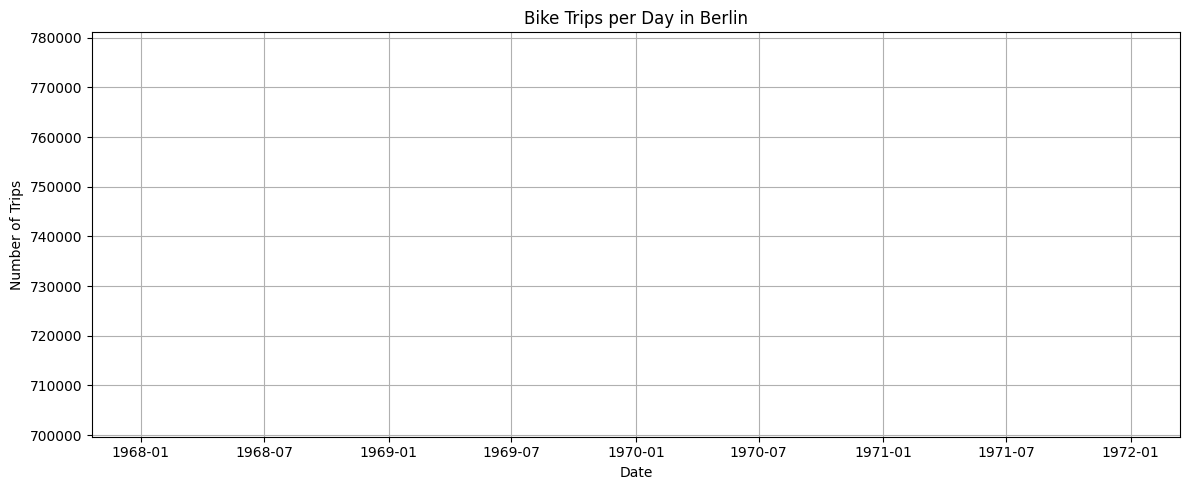

In [26]:
daily_trips = df.groupby('date').size()
daily_trips.plot(figsize=(12,5), title="Bike Trips per Day in Berlin")
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.grid()
plt.tight_layout()
plt.show()

In [27]:
!pip install matplotlib


check the exact column names in the DataFrame and correction in Debugging Errors
and Understanding Data Structure


In [28]:
print("Actual column names in df:")
print(df.columns.tolist())



Actual column names in df:
['duration_osrm', 'distance_osrm', 'lat_origin', 'long_origin', 'lat_destination', 'long_destination', 'time_origin', 'time_destination', 'providerId', 'bikeId', 'geometry', 'is_citylab', 'speed_osrm', 'duration_betweenorigindestination', 'speed_kmh', 'date', 'hour']


Generating Top 10 starting locations plot

Generating Top 10 starting locations plot (Step 4)...


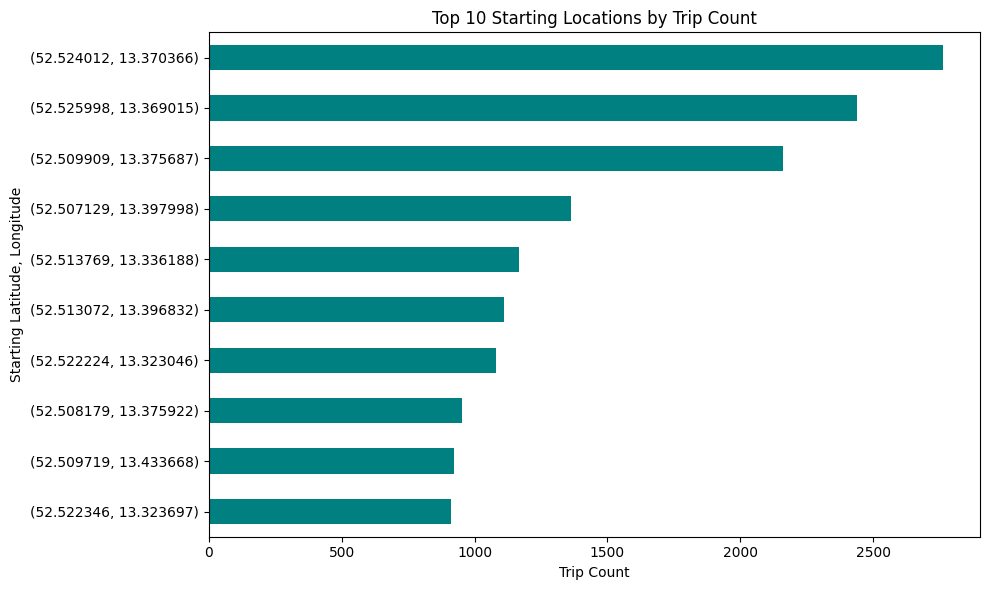

Top 10 starting locations plot generated successfully.
------------------------------


In [29]:
import matplotlib.pyplot as plt

# Optional: Normalize column names (already in good shape, but no harm)
df.columns = df.columns.str.strip().str.lower()

print("Generating Top 10 starting locations plot (Step 4)...")

# Use the correct column names: 'lat_origin' and 'long_origin'
if 'lat_origin' in df.columns and 'long_origin' in df.columns:
    # Group by 'lat_origin' and 'long_origin' to identify unique starting locations
    top_locations = df.groupby(['lat_origin', 'long_origin']).size().nlargest(10)

    # Plotting the top 10 starting locations
    plt.figure(figsize=(10, 6))
    top_locations.plot(kind='barh', title="Top 10 Starting Locations by Trip Count", color='teal')
    plt.xlabel("Trip Count")
    plt.ylabel("Starting Latitude, Longitude")
    plt.gca().invert_yaxis()  # Highest bar at the top
    plt.tight_layout()
    plt.show()

    print("Top 10 starting locations plot generated successfully.")
else:
    print("Error: 'lat_origin' or 'long_origin' columns not found for Step 4. Skipping this plot.")

print("-" * 30)


Trips Per Hour (Bar Chart)
Goal: See how usage varies by time of day.


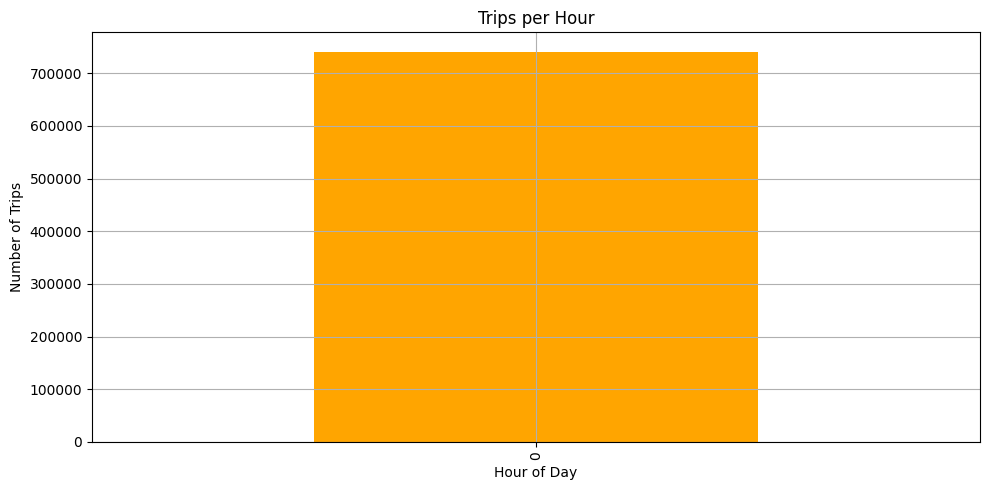

In [30]:
df['hour'] = pd.to_datetime(df['time_origin']).dt.hour
hourly_counts = df['hour'].value_counts().sort_index()

hourly_counts.plot(kind='bar', figsize=(10, 5), color='orange', title='Trips per Hour')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.grid(True)
plt.tight_layout()
plt.show()


Average Trip Speed by Hour (Line Plot)


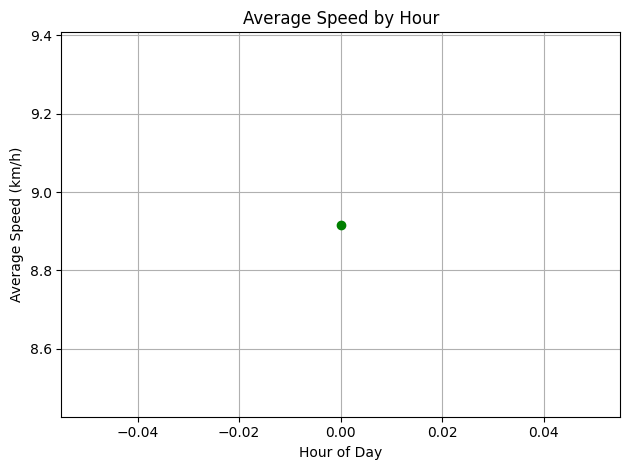

In [31]:
avg_speed_by_hour = df.groupby('hour')['speed_kmh'].mean()

avg_speed_by_hour.plot(kind='line', marker='o', color='green', title='Average Speed by Hour')
plt.xlabel("Hour of Day")
plt.ylabel("Average Speed (km/h)")
plt.grid(True)
plt.tight_layout()
plt.show()


Trip Density Heatmap (on a Map)
Goal: Show popular areas by trip start

In [ ]:
from folium.plugins import HeatMap

heat_df = df[['lat_origin', 'long_origin']].dropna()

m = folium.Map(location=[52.52, 13.405], zoom_start=12)
HeatMap(heat_df.values.tolist(), radius=8).add_to(m)
m


Clustered Marker Map of Origins
Goal: Group nearby start locations

In [ ]:
from folium.plugins import MarkerCluster

m = folium.Map(location=[52.52, 13.405], zoom_start=12)
cluster = MarkerCluster().add_to(m)

stations = df[['lat_origin', 'long_origin']].dropna().drop_duplicates().head(500)

for _, row in stations.iterrows():
    folium.Marker(location=[row['lat_origin'], row['long_origin']]).add_to(cluster)

m


Top 10 Bikes by Usage (Bar Chart)



In [ ]:
top_bikes = df['bikeid'].value_counts().head(10)
top_bikes.plot(kind='bar', color='purple', title='Top 10 Bikes by Trip Count')
plt.xlabel("Bike ID")
plt.ylabel("Trip Count")
plt.tight_layout()
plt.show()


Trip Duration Distribution (Histogram)


In [ ]:
df['duration_min'] = df['duration_betweenorigindestination'] / 60

df['duration_min'].plot.hist(bins=30, color='skyblue', title='Trip Duration (minutes)', edgecolor='black')
plt.xlabel("Duration (min)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Trip Route Samples (Line Map of Start→End)
Plot 100 random origin→destination lines

In [ ]:
import random
sample = df[['lat_origin', 'long_origin', 'lat_destination', 'long_destination']].dropna().sample(100)

m = folium.Map(location=[52.52, 13.405], zoom_start=12)

for _, row in sample.iterrows():
    folium.PolyLine(
        [(row['lat_origin'], row['long_origin']),
         (row['lat_destination'], row['long_destination'])],
        color='blue',
        weight=1,
        opacity=0.6
    ).add_to(m)

m


Install Required Library: Folium


In [ ]:
!pip install folium


Map of Starting Locations (Folium)
Goal: Visualize the geographic distribution of bike trip starting points.

In [ ]:
from IPython.display import display

print("Generating map visualization (Step 5)...")

if 'lat_origin' in df.columns and 'long_origin' in df.columns:
    m = folium.Map(location=[52.52, 13.405], zoom_start=12)

    # Limit to top 100 unique locations to avoid memory crash
    stations_for_map = df[['lat_origin', 'long_origin']].dropna().drop_duplicates().head(100)

    stations_for_map['station_name'] = stations_for_map.apply(
        lambda row: f"Lat: {row['lat_origin']:.3f}, Lon: {row['long_origin']:.3f}", axis=1
    )

    for _, row in stations_for_map.iterrows():
        folium.CircleMarker(
            location=[row['lat_origin'], row['long_origin']],
            radius=3,
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.7,
            popup=row['station_name']
        ).add_to(m)

    print("Map generated successfully (limited to 100 points).")
    display(m)
    m.save("starting_locations_map.html")
else:
    print("Error: 'lat_origin' or 'long_origin' columns not found for Step 5. Skipping map generation.")

print("-" * 30)

